# DBGSOM Paper Benchmarks

Reproducible results for the JOSS paper. Run the scripts first:

```bash
uv run python paper_benchmarks/clustering.py
uv run python paper_benchmarks/scaling.py
```


In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn.objects as so

RESULTS = Path("results")

## Clustering — Digits dataset


In [33]:
df_cluster = pd.read_csv(RESULTS / "clustering_digits.csv", index_col="Algorithm")
df_cluster

,n_prototypes,Time (s),QE,TE,ARI,Silhouette
Algorithm,,,,,,
DBGSOM,127,1.07,4.99,0.03,0.18,-0.03
MiniSom,132,3.51,4.99,0.14,0.16,0.00
SuSi,132,0.14,5.79,0.07,0.21,-0.06
torchsom,132,1.87,5.12,0.09,0.16,-0.02
KMeans,127,1.50,4.38,—,0.17,0.04


## Scaling — training time vs. N


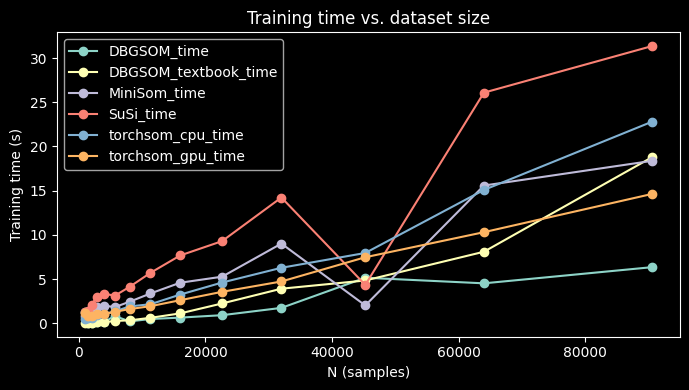

,DBGSOM_time,DBGSOM_n_nodes,DBGSOM_qe,DBGSOM_te,DBGSOM_textbook_time,DBGSOM_textbook_n_nodes,DBGSOM_textbook_qe,MiniSom_time,MiniSom_n_nodes,MiniSom_qe,SuSi_time,SuSi_n_nodes,SuSi_qe,torchsom_cpu_time,torchsom_cpu_n_nodes,torchsom_cpu_qe,torchsom_gpu_time,torchsom_gpu_n_nodes,torchsom_gpu_qe
N,,,,,,,,,,,,,,,,,,,
1000,1.244,39,0.9841,0.0130,0.059,39,0.9869,0.779,49,0.9781,1.286,49,1.2410,0.463,49,1.0364,1.164,49,0.9893
1414,0.054,42,0.9831,0.0000,0.043,41,0.9878,0.785,49,0.9895,1.359,49,1.1918,0.544,49,1.0581,0.843,49,0.9935
2000,0.069,63,0.9705,0.0310,0.070,62,0.9694,1.229,64,0.9818,2.084,64,1.0318,0.633,64,0.9944,0.838,64,0.9942
2828,0.107,84,0.9646,0.0644,0.087,80,0.9609,1.870,100,0.9643,2.996,100,0.9978,0.913,100,0.9864,1.011,100,0.9833
4000,0.136,93,0.9584,0.0625,0.128,85,0.9587,2.000,100,0.9700,3.358,100,0.9981,1.038,100,0.9879,1.064,100,0.9859
5656,0.824,84,0.9613,0.0645,0.260,121,0.9474,1.826,100,0.9687,3.108,100,0.9956,1.332,100,0.9848,1.291,100,0.9797
8000,0.213,108,0.9500,0.0602,0.330,106,0.9508,2.431,121,0.9691,4.113,121,0.9852,1.906,121,0.9830,1.603,121,0.9837
11313,0.482,141,0.9461,0.0671,0.616,142,0.9446,3.372,144,0.9682,5.707,144,0.9766,2.153,144,0.9846,1.932,144,0.9836
16000,0.639,172,0.9415,0.1109,1.115,166,0.9404,4.585,196,0.9672,7.667,196,0.9638,3.243,196,0.9801,2.607,196,0.9793


In [28]:
df_scale = pd.read_csv(RESULTS / "scaling.csv", index_col="N")
times = [
    "DBGSOM_time",
    "DBGSOM_textbook_time",
    "MiniSom_time",
    "SuSi_time",
    "torchsom_cpu_time",
    "torchsom_gpu_time",
]
qe = [
    "DBGSOM_qe",
    "DBGSOM_textbook_qe",
    "MiniSom_qe",
    "SuSi_qe",
    "torchsom_cpu_qe",
    "torchsom_gpu_qe",
]

fig, ax = plt.subplots(figsize=(7, 4))
for col in df_scale[times]:
    ax.plot(df_scale.index, df_scale[col], marker="o", label=col)
    # ax.plot(df_scale["DBGSOM_textbook_n_nodes"], df_scale[col], marker="o", label=col)

ax.set_xlabel("N (samples)")
ax.set_ylabel("Training time (s)")
ax.set_title("Training time vs. dataset size")
ax.legend()
plt.tight_layout()
# plt.savefig(RESULTS / "scaling_plot.png", dpi=150)
plt.show()
df_scale

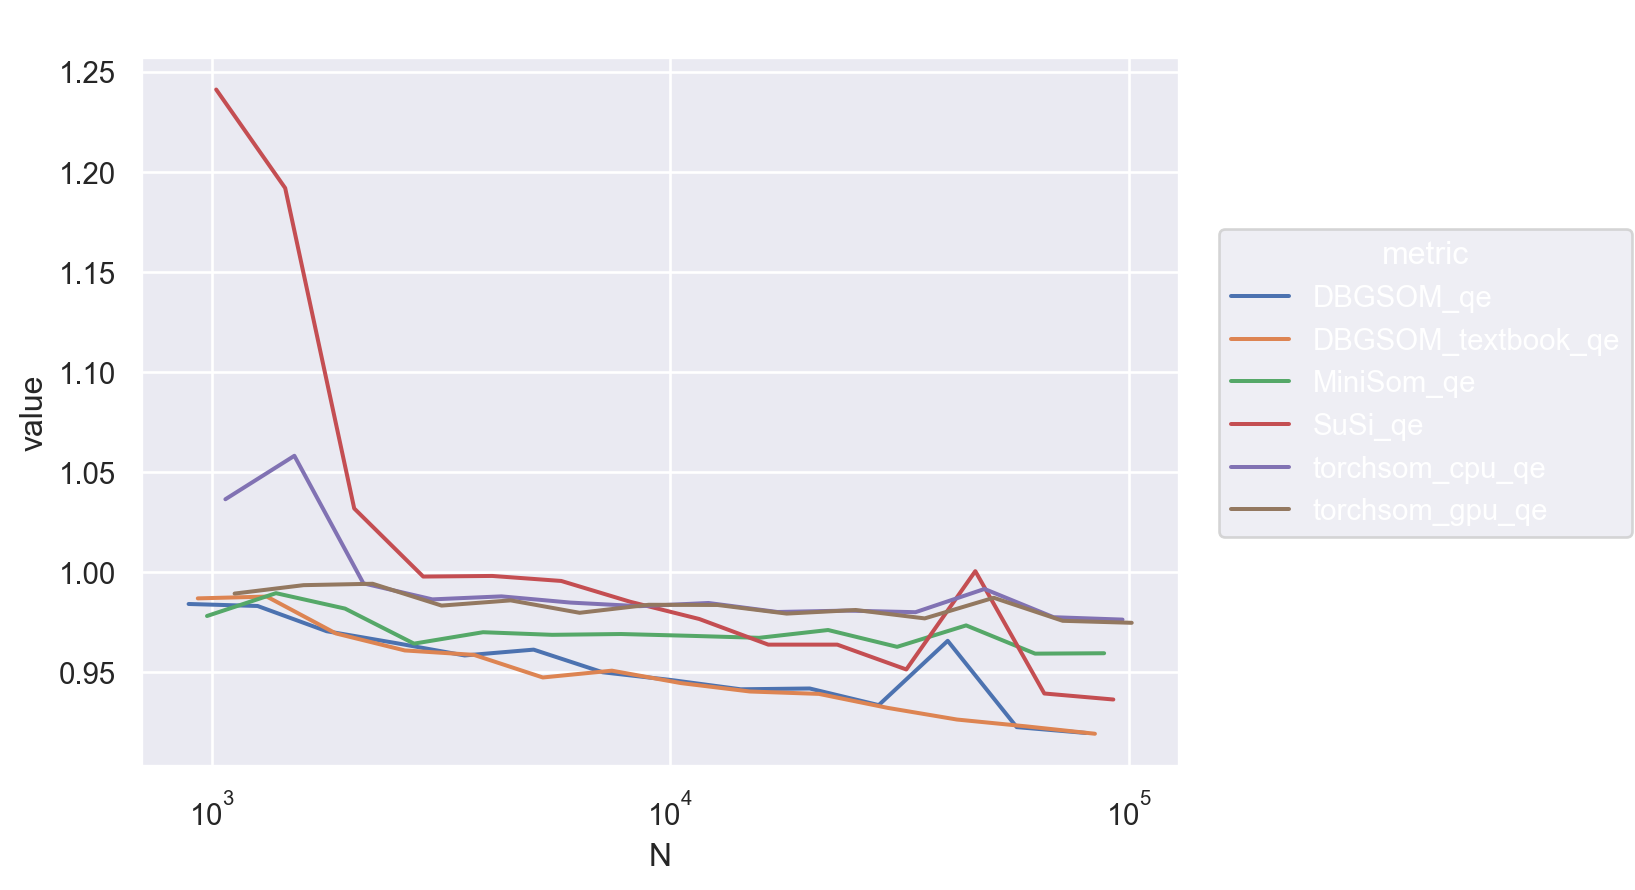

In [29]:
df_long = df_scale.reset_index()[["N"] + qe].melt(
    id_vars="N", var_name="metric", value_name="value"
)

so.Plot(df_long, x="N", y="value", color="metric").add(so.Line(), so.Dodge()).scale(
    x="log"
).label(title="X")

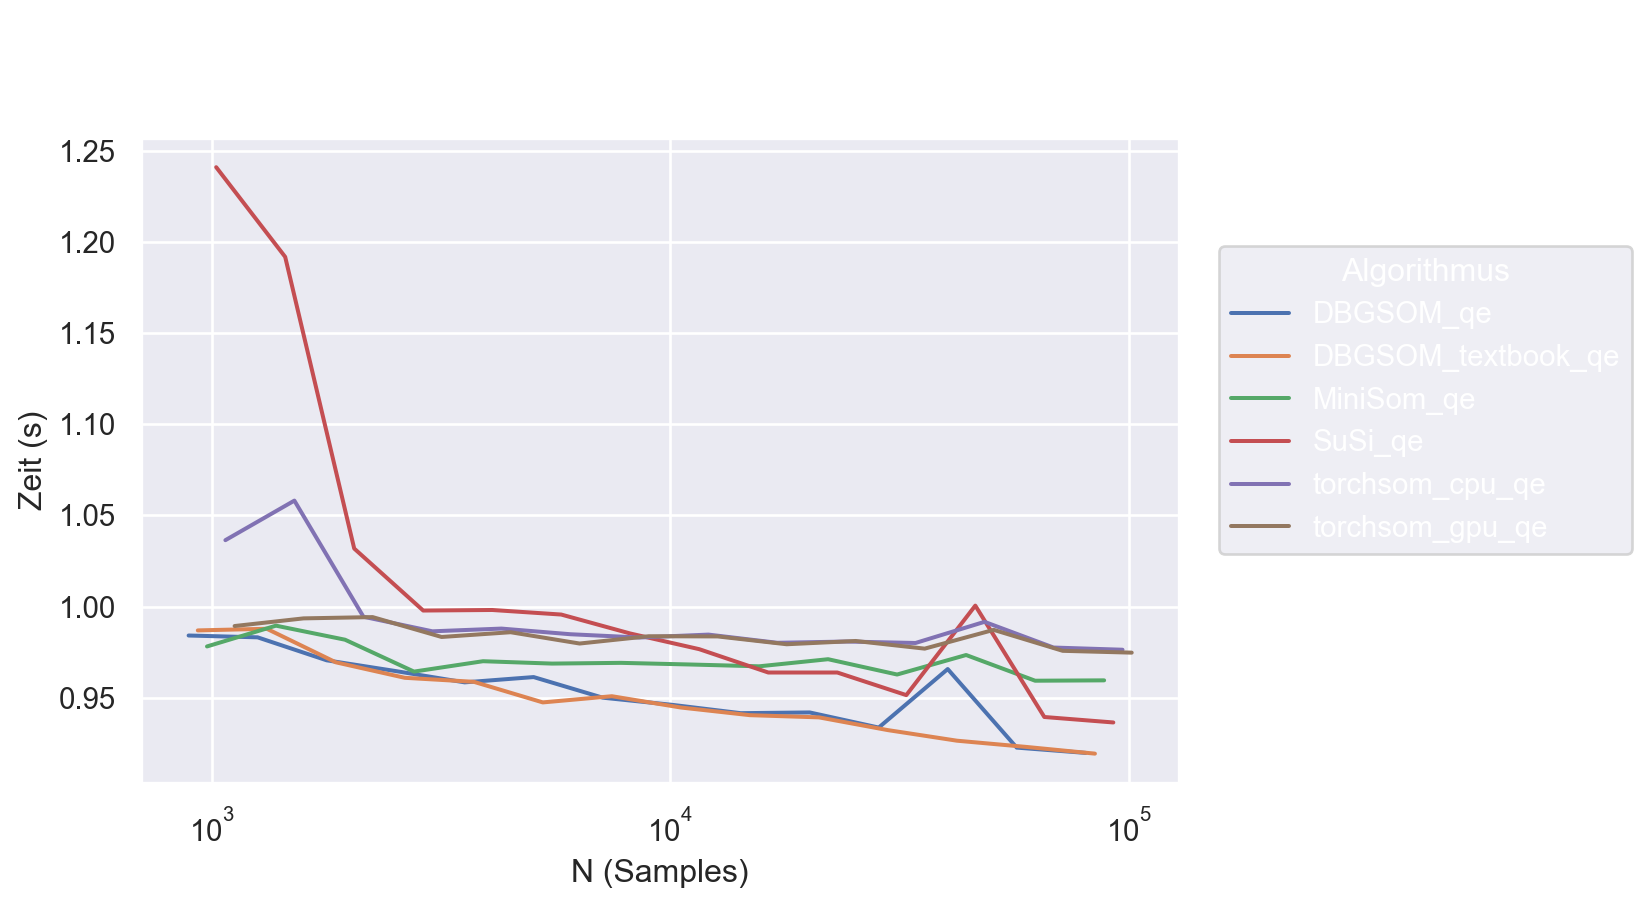

In [30]:
p = (
    so.Plot(df_long, x="N", y="value", color="metric")
    .add(so.Line(), so.Dodge())
    .label(
        title="Training Zeit vs. Datensatzgröße",
        x="N (Samples)",
        y="Zeit (s)",
        color="Algorithmus",
    )
    .scale(x="log")
)
plotter = p.plot()
plotter._figure.suptitle("Training Zeit vs. Datensatzgröße")
plotter

In [37]:
N_samples = 100000
500 * 500

250000

In [39]:
N_samples**0.5 * 500**0.5

7071.067811865476